In [12]:
from shared.preface import *


def UTIL_select_neutrinos_momentum_filter(vectors, nu_mass, z_select=-1):
    # Extract velocities and positions and attach units
    zBack_velocities = vectors[:, z_select, 3:6]*kpc/s

    # note on selection for with-gravity
    # 52000 with z0 velocities (65% of neutrinos)
    # 65381 with zBack velocities (81% of neutrinos)

    # Convert velocities to momentum magnitudes
    momentum = zBack_velocities * nu_mass
    mags = UTIL_magnitudes(momentum)

    # Filter based on momentum values
    selection = (mags >= 0.01*T_CNB) & (mags <= 10*T_CNB)
    neutrinos = np.count_nonzero(selection)

    percent = neutrinos/len(vectors)*100
    print(f'{neutrinos} ({percent:.1f}%) neutrinos selected.')

    return vectors[selection]


def UTIL_magnitudes(vectors):
    return np.linalg.norm(vectors, axis=-1)

def UTIL_generate_redshift_array(zBack, num_points):
    
    z_values = np.logspace(0, np.log10(zBack + 1), num_points) - 1
    z_values[-1] = zBack  # Ensure last value is exactly zBack

    return z_values

h = 0.674
H0 = h * 100 * km/s/Mpc
Omega_R = 9.23640e-5
Omega_M = 0.3111
Omega_L = 1.-Omega_M-Omega_R

def CALC_Hubble_rate(z):
    # Hubble rate in "numerical" units.
    return H0*np.sqrt(Omega_R*(1+z)**4 + Omega_M*(1+z)**3 + Omega_L)


def CALC_Chi_integrand(z, p_0, m_nu):
    # Comoving distance integral for massive particles
    integrand = p_0/CALC_Hubble_rate(z)/np.sqrt(p_0**2 + m_nu**2/((1+z)**2))
    
    # Integrand is returned with preface units
    return integrand


def CALC_LSS_distance(z_LSS, p_0=1.0, m_nu=0.0):

    # Logarithmically spaced redshifts starting at zero, ending at z_LSS
    z_int_range = UTIL_generate_redshift_array(z_LSS, num_points=100)

    # Comoving distance (Chi) to last scattering surface (LSS)
    integrand = CALC_Chi_integrand(z_int_range, p_0, m_nu)
    Chi_LSS = np.trapz(integrand, x=z_int_range)

    return Chi_LSS


def PLOT_distances_histogram_log_bins(
        distances, Fermi_Dirac=None, CMB_LSS=False, ax_lims=None):
    """
    Plot a histogram of distances with logarithmically spaced bins.
    """

    # Avoiding zero distance for log scale
    distances_above0 = distances[distances > 0]

    # From kpc to Mpc
    distances_Mpc = distances_above0/1e3

    # Generating logarithmically spaced bins
    log_bins = np.logspace(
        np.log10(np.min(distances_Mpc)), np.log10(np.max(distances_Mpc)), 100
    )
    
    fig = plt.figure()
    ax = fig.add_subplot(111)

    # Plot simulation distances
    ax.hist(
        distances_Mpc, bins=log_bins, 
        color='blue', label='CNB simulation', alpha=0.8)

    # Plot Fermi-Dirac sampled momentum comoving distances
    if Fermi_Dirac is not None:
        Fermi_Dirac_Mpc = Fermi_Dirac/1e3
        ax.hist(
            Fermi_Dirac_Mpc, bins=log_bins, 
            color='orange', label='Fermi-Dirac no-gravity', alpha=0.7)

    # Plot Distance to CMB LSS
    if CMB_LSS:
        z_end_sim = 4.0
        CMB_LSS_dist = CALC_LSS_distance(z_end_sim)/(Mpc/h)
        ax.axvline(CMB_LSS_dist, c='red', ls='dashed')

        # Compute geometric mean for y-position of text
        y_lower, y_upper = ax.get_ylim()
        # y_mid = np.sqrt(y_lower * y_upper)
        y_mid = (y_upper - y_lower)/2

        # Add rotated text
        ax.text(
            CMB_LSS_dist, y_mid, 'CMB LSS', color='red', 
            rotation=90, va='center', ha='right')

    ax.set_xscale('log')
    ax.set_title("Distances at z=4 (Log Bins)")
    ax.set_xlabel("Distance [Mpc] (or is it Mpc/h?)")
    ax.set_ylabel("Number of Particles")
    ax.legend(loc='upper left')

    if ax_lims is not None:
        ax.set_xlim(ax_lims[0], ax_lims[1])
        ax.set_ylim(ax_lims[2], ax_lims[3])

    plt.savefig("distances_histogram_log_bins.pdf", bbox_inches='tight')
    plt.show()
    plt.close()

ic| nu_vecs.shape: (768000, 2, 6), nu_dens.shape: (768, 100)


500736 (65.2%) neutrinos selected.


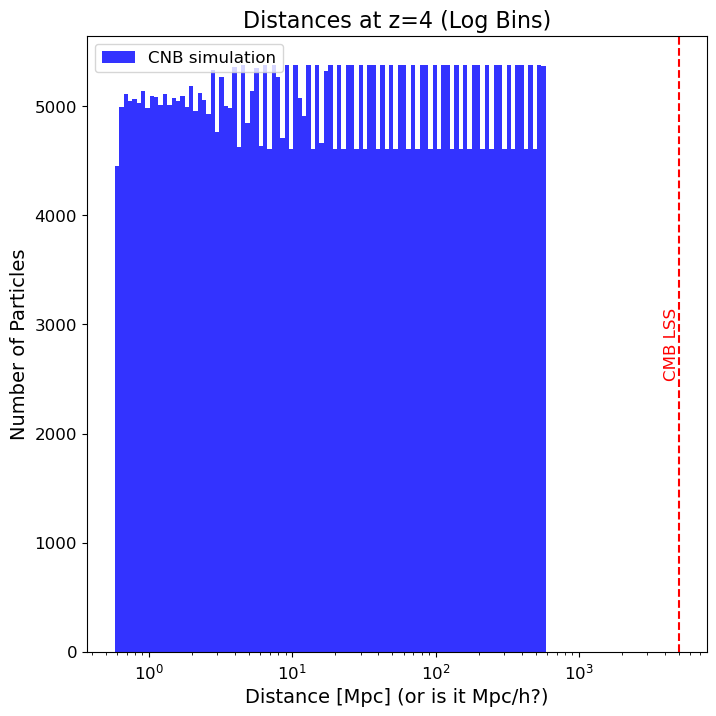

In [14]:
sim_folder = "L025N752/DMONLY/SigmaConstant00/no_gravity"
nu_vecs = jnp.load(f"{sim_folder}/neutrino_vectors_numerical_no_gravity_all_sky.npy")
nu_dens = jnp.load(f"{sim_folder}/number_densities_numerical_no_gravity_all_sky.npy")
ic(nu_vecs.shape, nu_dens.shape)

# Specified neutrino selection
nu_mass_choice = 0.05*eV
cut_vectors = UTIL_select_neutrinos_momentum_filter(
    nu_vecs, nu_mass_choice, z_select=0)

# Split into position and velocities
Zimmer_pos = cut_vectors[...,:3]
Zimmer_vel = cut_vectors[...,3:]

Zimmer_distances_zBack = UTIL_magnitudes(Zimmer_pos[:,-1,:])

PLOT_distances_histogram_log_bins(
    distances=Zimmer_distances_zBack, Fermi_Dirac=None, CMB_LSS=True)

Plot idea (for sim output with gravity): Display the change in velocities, and highlight neutrinos (e.g. with different color), which have switched sign at least once along an axis during their travel (expecting low velocity neutrinos mostly), due to gravity.

In [19]:
np.sum(nu_dens[:,-1]/N0)

Array(0.99999994, dtype=float32)